# [Bacterial Colony Growth](@id Bacteries)

In this example, we are going to create a bacterial model and grow a colony using it.

 - The implementation of the force interaction dynamics is the one presented by [Volfson et al. (2008)](https://www.pnas.org/doi/abs/10.1073/pnas.0706805105)
 - We use GPU accelerated dynamics

As described in other models, it is advised that the models are constructed by parts to avoid having to find bugs in a very complex system. Hence, we will split the model in two parts:

 - Forces model
 - Growth model

## Load the packages

In [1]:
@info "Threads Julia" Threads.nthreads()
BLAS.set_num_threads(8)  # por ejemplo

using LinearAlgebra; @info "Threads BLAS" BLAS.get_num_threads()
@info "CPU lógicos" Sys.CPU_THREADS

┌ Info: Threads Julia
│   Threads.nthreads() = 10
└ @ Main c:\Users\julia\OneDrive\Escritorio\phd\Bacteria_ABM\ABM_CBM\proves\Tod's\Tods_c\Line\v6\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W2sZmlsZQ==.jl:1


UndefVarError: UndefVarError: `BLAS` not defined

In [2]:
using Base.Threads
println("Usando ", nthreads(), " threads 😎")

Usando 10 threads 😎


In [4]:
# import Pkg
# Pkg.activate("../")
# Pkg.instantiate()


In [5]:
# import Pkg; Pkg.add(["Revise", "GLMakie"])

In [6]:
# using Revise
# using CellBasedModels
# using CUDA
# using Distributions
# using GLMakie
# # using GeometryBasics
# import GLMakie: Point3f, Cylinder, Sphere, NoShading #Can be changes to Cairo or CLMakie

In [7]:
import Pkg

# Activa el entorno del proyecto
Pkg.activate("../../../../../")


# Resuelve y asegura dependencias
Pkg.resolve()
Pkg.instantiate()


# Carga los paquetes de forma ordenada
using Revise
using CellBasedModels
ENV["JULIA_CUDA_USE_BINARYBUILDER"] = false  # (opcional, fuerza compilación local)
using CUDA
CUDA.set_runtime_version!(v"12.2")
using Distributions
using CairoMakie
using JSON

# Importa funciones específicas después
import CairoMakie: Point3f, Cylinder, Sphere, NoShading

CairoMakie.activate!()


  Activating project at `c:\Users\julia\OneDrive\Escritorio\phd\Bacteria_ABM\ABM_CBM`
  No Changes to `C:\Users\julia\OneDrive\Escritorio\phd\Bacteria_ABM\ABM_CBM\Project.toml`
    Updating `C:\Users\julia\OneDrive\Escritorio\phd\Bacteria_ABM\ABM_CBM\Manifest.toml`
  [05823500] ↑ OpenLibm_jll v0.8.1+2 ⇒ v0.8.1+4
  [8e850b90] ↑ libblastrampoline_jll v5.8.0+1 ⇒ v5.11.0+0
Precompiling packages...
  32011.8 ms  ✓ CUDA
   2691.3 ms  ✓ ArrayInterface → ArrayInterfaceCUDAExt
   2727.7 ms  ✓ CUDA → ChainRulesCoreExt
   2853.7 ms  ✓ CUDA → SpecialFunctionsExt
   3343.1 ms  ✓ LinearSolve → LinearSolveCUDAExt
  13878.9 ms  ✓ CellBasedModels
  6 dependencies successfully precompiled in 73 seconds. 434 already precompiled.
┌ Info: Configure the active project to use CUDA 12.2; please re-start Julia for this to take effect.
└ @ CUDA C:\Users\julia\.julia\packages\CUDA\jdJ7Z\lib\cudadrv\version.jl:82


## Forces model

We already use the defined forces model that is implemented in CBqodels. This is an exact copy of the rod model that you can find already predefined in `Models/rods.jl`. You can check the `Models` section of the documentation for more details.


In [8]:
rod2D = ABM(2,
    agent = Dict(
            :theta=>Float64,
            :d=>Float64,
            :l=>Float64,
            :fx=>Float64,
            :fy=>Float64,
            :W=>Float64,
        ),    #Local Interaction Parameters

    model = Dict(
            :E=>Float64,
            :eta=>Float64,

        ),        #Global parameters

    agentODE = quote

        fx = 0
        fy = 0
        W = 0
        @loopOverNeighbors i2 begin

            #Use the model provided in the documentation
            Fijx, Fijy, Wij = CBMModels.repulsiveForces_rods(x,y,d,l,theta,
                                    x[i2],y[i2],d[i2],l[i2],theta[i2],eta, E)

            #Append the repulsive forces
            fx += Fijx
            fy += Fijy
            W += Wij
            
        end

        #Equations
        dt(x) =  fx 
        dt(y) =  fy 
        dt(theta) =  W
    end,

    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=4),
    platform=CPU(),
    agentAlg = CBMIntegrators.Heun()
);


### Initialize a coqunity with two bacteries and check forces

In [9]:
com = Community(rod2D,
            N=30,
            dt=0.0001,
            simBox = [-10 10;-10 10.],
            );


#Natural units scales
m = 1.E3 #g
t = 1/(60*60) # h
d = 1.E6 #um


com.E=6* 1.E5 *m/(t^2*d) #Pa
com.eta=150 *m/(t^2*d) #Pa h
 

com.d = 1.        
com.l = 3.99      



com.x = 0
com.y = 0
com.theta = 0;


In [10]:
com.N

30

In [11]:
for i in 1:com.N
    com.theta[i] = rand() * 2π
    com.x[i] = rand()*10-5
    com.y[i] = rand()*10-5
    com.l[i] = 3.0
    com.d[i] = 1.0

end

In [12]:
evolve!(com,steps=10000,saveEach=100,preallocateAgents=com.N)

In [13]:
function plotAgents2D!(ax, x, y, d, l, angle, p; colormap=:inferno, kargs...)
    for (xi, yi, li, di, ai, pi) in zip(x, y, l, d, angle, p)



            colorval = pi
            # colormap = :inferno
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [colorval],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [colorval],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [colorval],
                colormap = colormap,
                kargs...
            )

    end
    return
end


plotAgents2D! (generic function with 1 method)

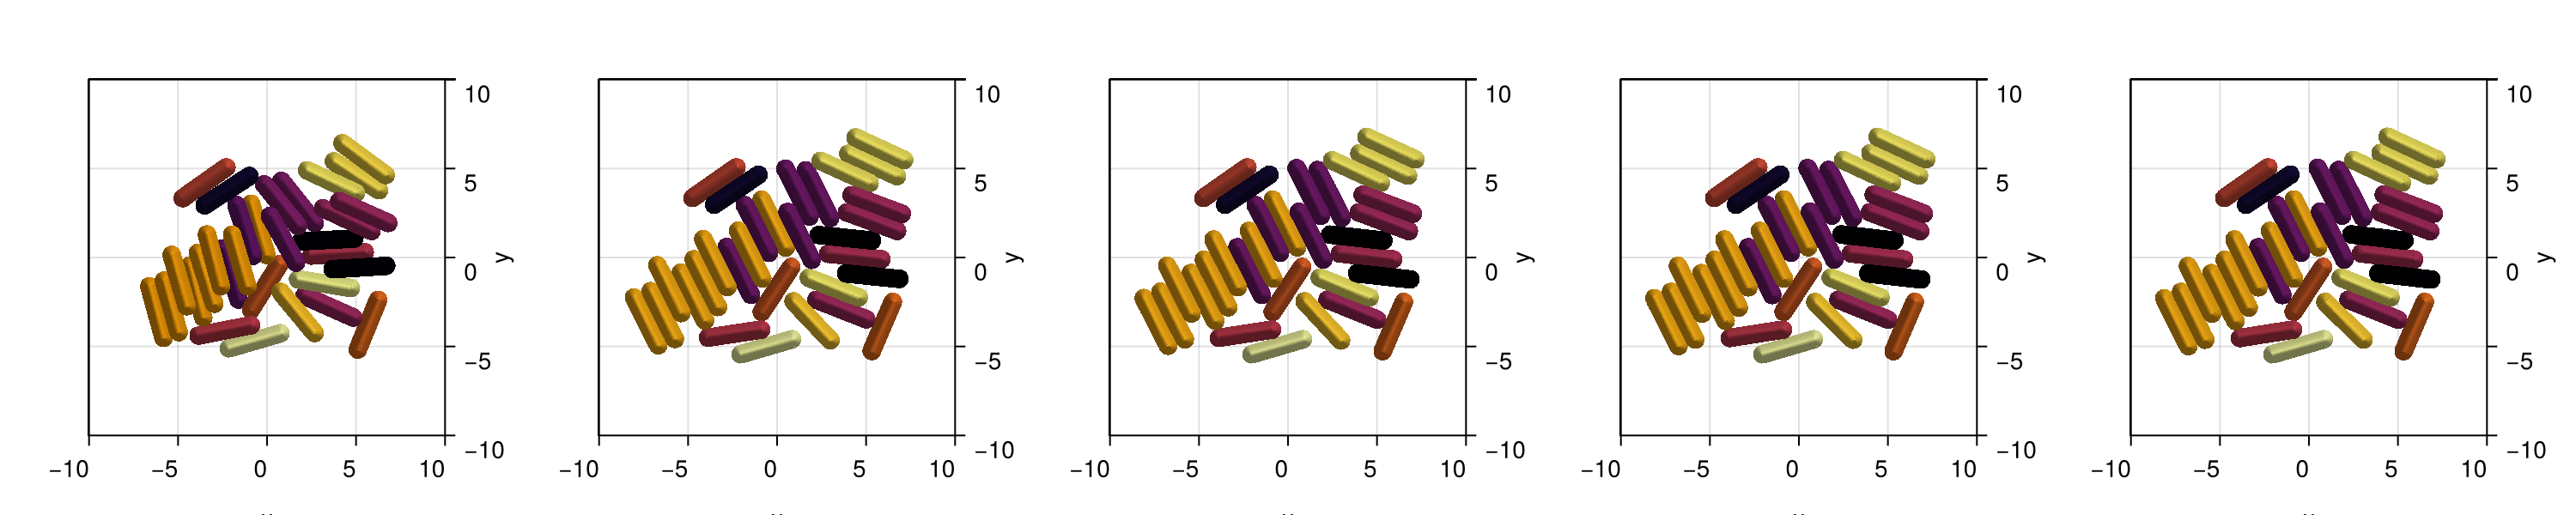

CairoMakie.Screen{IMAGE}


In [14]:
fig = Figure(size=(1500,300))

for (i,j) in enumerate([1:round(Int,length(com)/4):length(com);length(com)])
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotAgents2D!(
    ax,
    com[j][:x],
    com[j][:y],
    com[j][:d],
    com[j][:l],
    com[j][:theta],
    com[j][:theta],
    colorrange = (0, 2*pi)
)

    xlims!(-10,10)
    ylims!(-10,10)
end

display(fig)

In [15]:

function log_community_state(parameters::OrderedDict, t::Int, path::String = "Tods_c.txt")
    # Convert keys to strings so JSON can serialize them
    string_keys = Dict(string(k) => v for (k, v) in parameters)
    # Build entry
    entry = Dict("t" => t, "parameters" => string_keys)
    # Save as a JSON line
    open(path, "a") do io
        println(io, JSON.json(entry))
    end
end


function load_parameters_log(path::String = "Tods_c.txt")
    log = Dict{Int, OrderedDict{Symbol, Any}}()
    for line in eachline(path)
        entry = JSON.parse(line)
        t = entry["t"]
        raw_params = entry["parameters"]
        params = OrderedDict(Symbol(k) => v for (k, v) in raw_params)
        log[t] = params
    end
    times = sort(collect(keys(log)))
    com_array = [log[t] for t in times]
    return com_array, times
end



load_parameters_log (generic function with 2 methods)

## Growth model

We construct over the forces model to add bacterial growth and cell division rules.

In [16]:
function plotMixedAgents2D!(ax, x, y, d, l, angle, type, p; kargs...)
    for (xi, yi, li, di, ai, ti, pi) in zip(x, y, l, d, angle, type, p)


        if ti== 0  # rods
            # colorval = pi
            # colormap = :Blues
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:green],
                # colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:green],

                # colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [:green],

                kargs...
            )
        else  # puntos
            colorval = pi
            colormap = :Reds
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:orange],
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:orange],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [:orange],
                colormap = colormap,
                kargs...
            )
        end

    end
    return
end


plotMixedAgents2D! (generic function with 1 method)

In [17]:
rods2dGrowth = ABM(2,
    baseModelInit = [rod2D],

    agent = Dict(
                :lTarget => Float64,
                :growth=>Float64,
            ),

    model = Dict(
                :σlTarget=>Float64,
                :lMax=>Float64,
            ),


 
    agentODE = quote  
        
        dt(l) = l*growth

    end,

    agentRule = quote #Bound cells

        #Add division
        if l > lTarget
            ww = CBMDistributions.uniform(-1,1)*1.E-2 #To add some random torque at division time

            # ww = 0 #To add some random torque at division time
            #Add a new cell
            @addAgent(
                    x=(l+d)/4*cos(theta)+x,
                    y=(l+d)/4*sin(theta)+y,
                    l=(l-d)/2,
                    W=ww,
                    lTarget = CBMDistributions.uniform(lMax-σlTarget,lMax+σlTarget),)
            #Add a second cell
            @addAgent(
                    x=-(l+d)/4*cos(theta)+x,
                    y=-(l+d)/4*sin(theta)+y,
                    l=(l-d)/2,
                    lTarget = CBMDistributions.uniform(lMax-σlTarget,lMax+σlTarget), #New target length at which the bactery should divide
                    W=ww)
            #Remove the old cell
            @removeAgent()
        end

    end,

    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=4),
    platform=CPU(),
    agentAlg=CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
);

## Grow colony from one cell

In [19]:
com = Community(rods2dGrowth,
            N=100,
            dt=0.0001,
            simBox = [-100 100;-100 100.],
            NMedium=[100,100],
            );

#Natural units scales
m = 1.E3 #g
t = 1/(60*60) # h
d = 1.E6 #um


com.E=1* 1.E6 *m/(t^2*d) #Pa
com.eta=200 *m/(t^2*d) #Pa h
# com.Eta =com.eta

# com.PGA=0
# com.alpha_PGA = 10
# com.delta_PGA = 1
# com.D_PGA = 20
# com.v =1
 

com.growth = 5
com.lMax = 4.     
com.σlTarget = 1. 

 
com.d = 1.        
com.l = 3.99      
com.lTarget = 4.  

# com.D_c = 1
# com.cm = 1 #Medium concentration
# com.Kc = 0.3 #Half saturation constant for the medium
# com.beta_c = 0.01 #Growth rate of the cells in the medium
# com.alpha_c = 0.3  #Decay rate of the cells in the medium
# com.Kch = 0.2 #Half saturation constant for the medium
# com.nh = 2 #Hill coefficient for the medium

# com.rmax = 0.0 #Maximum growth rate of the cells in the medium
# com.gamma_c = 0.1 #Decay rate of the cells in the medium
# com.gamma_d = 0.1 #Decay rate of the cells in the medium
# com.a_c = 0.0001 #Decay rate of the cells in the medium
# com.a_d = 0.0001 #Decay rate of the cells in the medium

# com.c=1
com.x = 0
com.y = 0
com.theta = 0;

In [21]:
for i in 1:com.N
    com.theta[i] = rand() * 2π
    # com.x[i] = rand()*10-5
    # com.y[i] = rand()*10-5
    com.l[i] = 3+rand()*1.0
    # com.d[i] = 1.0

end

In [22]:
com.NMedium[1]/2

50.0

In [23]:
steps=Int(round(0.7/com.dt))
# saveEach=steps/100
saveEach=Int(round(10/com.dt))/100
# steps=100000
# saveEach=10000
N=com.N*3 

loadToPlatform!(com,preallocateAgents=N)
open("Tods_c.txt", "w") do f
    # clear file at start
end

for step in 1:steps
    
    step!(com)
    


    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step)
        loadToPlatform!(com,preallocateAgents=N)
    end
end

bringFromPlatform!(com)


Step 1000 N: 200
Step 2000 N: 261
Step 3000 N: 400
Step 4000 N: 527
Step 5000 N: 799
Step 6000 N: 1037
Step 7000 N: 1593


In [24]:
prev_steps = 0
steps=Int(round(0.8/com.dt))
com.growth = 0
open("Tods_c.txt", "w") do f
    # clear file at start
end

loadToPlatform!(com,preallocateAgents=N)


for step in 1+prev_steps:steps
    
    step!(com)


    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step)
        loadToPlatform!(com,preallocateAgents=N)
    end
end
bringFromPlatform!(com)

Step 1000 N: 1593
Step 2000 N: 1593
Step 3000 N: 1593
Step 4000 N: 1593
Step 5000 N: 1593
Step 6000 N: 1593
Step 7000 N: 1593
Step 8000 N: 1593


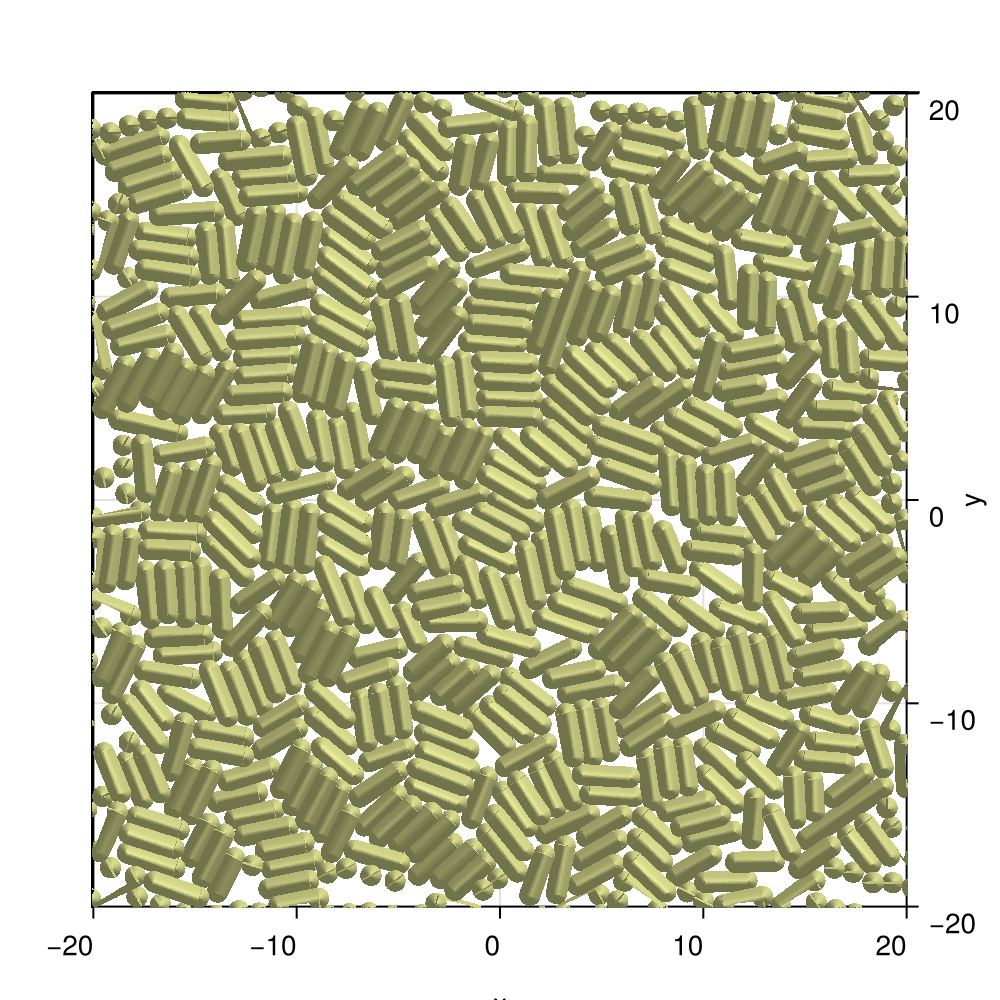

CairoMakie.Screen{IMAGE}


In [25]:
com_load,times=load_parameters_log("Tods_c.txt")

fig = Figure(size=(500,500))

js = length(com_load)
# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate([js])
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:d],
    colorrange = (0, 0.03)
    )

    xlims!(-20,20)
    ylims!(-20,20)
end

display(fig)

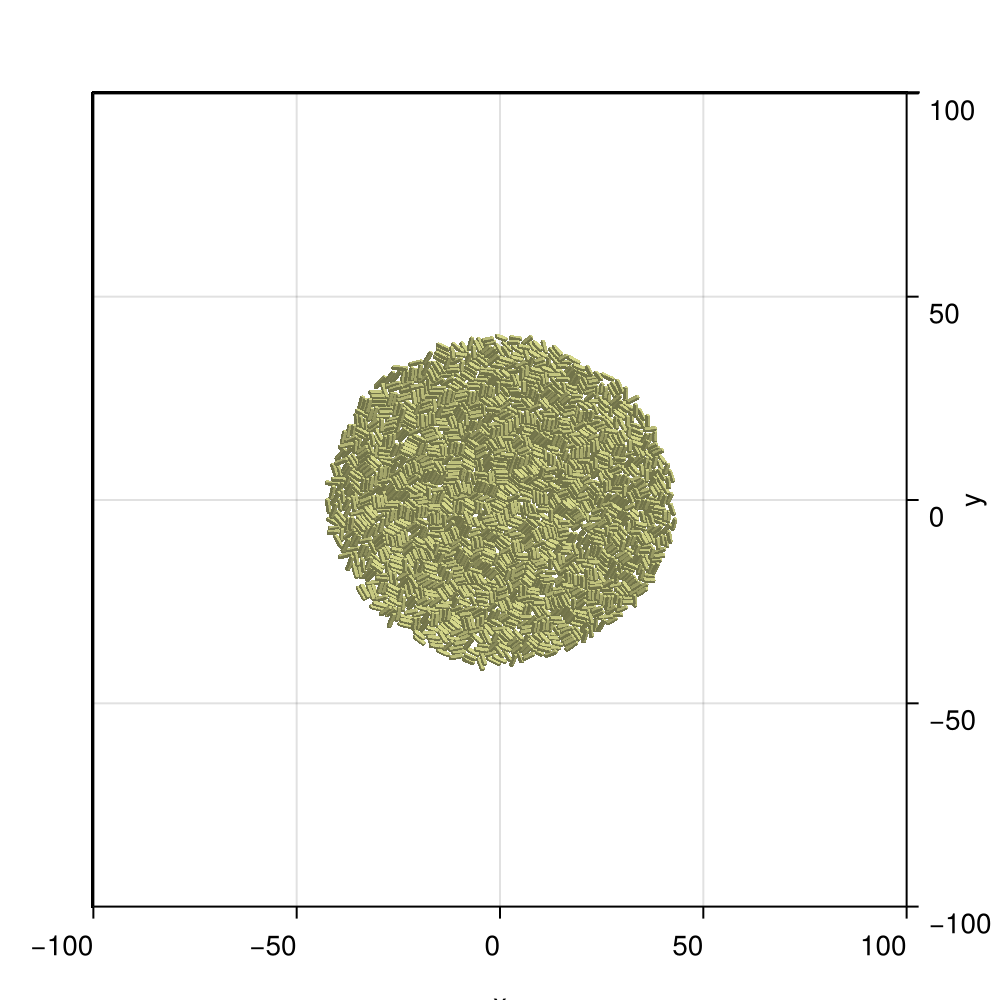

CairoMakie.Screen{IMAGE}


In [26]:
com_load,times=load_parameters_log("Tods_c.txt")

fig = Figure(size=(500,500))

js = length(com_load)
# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate([js])
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:d],
    colorrange = (0, 0.03)
    )

    xlims!(-100,100)
    ylims!(-100,100)
end

display(fig)

In [27]:
saveJLD2("biofilm0.jld2",com)

In [28]:
com_aux = loadJLD2("biofilm0.jld2")

Community with 1593 agents.


In [29]:
rods_PGA = ABM(2,

    agent = Dict(
                :theta=>Float64,
                :d=>Float64,
                :l=>Float64,
                :fx=>Float64,
                :fy=>Float64,
                :W=>Float64,
                :lTarget => Float64,
                :type => Int,
                :growth=>Float64,
                :Kc => Float64, #Half saturation constant for the medium
                :generation => Int,
                :v => Float64, 
                :r => Float64, #Distance to the origin
                :g2 => Float64, #Growth rate of the cells in the medium
                :eta=>Float64,
            ),

    model = Dict(
                :E=>Float64,
                :σlTarget=>Float64,
                :lMax=>Float64,
                :D_c => Float64,
                :cm => Float64, #Medium concentration
                :beta_c => Float64, #Growth rate of the cells in the medium
                :alpha_c => Float64,  #Decay rate of the cells in the medium
                :delta_PGA=>Float64, #Decay rate of the medium
                :alpha_PGA=>Float64, #Decay rate of the cells in the medium
                :Kch => Float64, #Half saturation constant for the medium
                :nh => Int, #Hill coefficient for the medium
                :rmax => Float64, #Maximum growth rate of the cells in the medium
                :gamma_c => Float64, #Decay rate of the cells in the medium
                :gamma_d => Float64, #Decay rate of the cells in the medium
                :a_c => Float64, #Decay rate of the cells in the medium
                :a_d => Float64, #Decay rate of the cells in the medium
                :alpha_DPGA => Float64, #Decay rate of the cells in the medium
            ),
    
    medium = Dict(
        :D_eff => Float64, #Distance to the origin
        :alpha_eff => Float64, #Decay rate of the cells in the medium
        :c => Float64,        #Add a medium parameter
        :PGA => Float64,        #Add a medium parameter
        :Hx => Float64,  #Add a medium parameter
        :Hy => Float64,        #Add a medium parameter
        :Eta => Float64,
        :D_PGA=>Float64, #Diffusion coefficient for the medium
        :Eta_eff => Float64
    ),

 
    agentODE = quote  
        
        dt(l) = l*growth*c/(Kc+c) + l*g2*c^nh/(Kch^nh+c^nh)

        fx = 0
        fy = 0
        W = 0
        @loopOverNeighbors i2 begin
            #Use the model provided in the documentation
            Fijx, Fijy, Wij = CBMModels.repulsiveForces_rods(x,y,d,l,theta,
                                    x[i2],y[i2],d[i2],l[i2],theta[i2],(1 .+Eta_eff) .*eta, E)

            #Append the repulsive forces
            fx += Fijx
            fy += Fijy
            W += Wij

            fx-= v * Hx
            fy-= v * Hy
            
        end

        #Equations
        dt(x) =  fx 
        dt(y) =  fy 
        dt(theta) =  W
    end,

    agentRule = quote #Bound cells

        #Add division
        if l > lTarget
            ww = CBMDistributions.uniform(-1,1)*1.E-2 #To add some random torque at division time

            # ww = 0 #To add some random torque at division time
            #Add a new cell
            @addAgent(
                    x=(l+d)/4*cos(theta)+x,
                    y=(l+d)/4*sin(theta)+y,
                    l=(l-d)/2,
                    W=ww,
                    lTarget = CBMDistributions.uniform(lMax-σlTarget,lMax+σlTarget),
                    )
            #Add a second cell
            @addAgent(
                    x=-(l+d)/4*cos(theta)+x,
                    y=-(l+d)/4*sin(theta)+y,
                    l=(l-d)/2,
                    lTarget = CBMDistributions.uniform(lMax-σlTarget,lMax+σlTarget), #New target length at which the bactery should divide
                    W=ww)
            #Remove the old cell
            @removeAgent()
        end
        
        c += (-l*beta_c*c/(Kc+c))*dt
        if type !=0
            PGA += (alpha_PGA*c^nh/(Kch^nh+c^nh))*dt
        end
        # r = sqrt(x ^ 2 + y ^ 2) #Distance to the origin
        # if r> rmax
        #     rmax=r
        # end
        
  
    end,

    #Medium dynamics with dirichlet conditions and a wall that is as oscillating source of material
    mediumODE=quote 
        Eta_eff = Eta*(1-PGA/(1 + PGA))
        # D_PGA = alpha_DPGA./ Eta .+ Eta[1,1] 


        if @mediumInside()
            dt(c) =D_eff*(@∂2(1,c)+@∂2(2,c)) - alpha_eff*(c - cm)
            # dt(PGA) =  - delta_PGA*PGA
            # dt(PGA) = D_PGA*(@∂2(1,PGA)+@∂2(2,PGA)) - delta_PGA*PGA
            dt(PGA) = D_eff*(@∂2(1,PGA)+@∂2(2,PGA)) - delta_PGA*PGA
            Hx = @∂(1,PGA) 
            Hy = @∂(2,PGA)
        elseif @mediumBorder(1,-1) 
            c = cm
            PGA = 0
        elseif @mediumBorder(1,1)
            c = cm
            PGA = 0

        elseif @mediumBorder(2,-1)
            c = cm
            PGA = 0

        elseif @mediumBorder(2,1)
            c = cm
            PGA = 0

        end

    end,

    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=4),
    platform=CPU(),
    agentAlg=CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
);

In [30]:
com_aux.x

1593-element Vector{Float64}:
  29.1458129572756
  15.779921109291639
 -23.03043206987618
   4.6140234540037035
  12.371422926614256
 -22.953799367550147
  -3.0976781980419266
   6.186060477738073
 -20.503552263094964
 -28.326837101286678
   ⋮
   9.59123749942022
  19.7372627645902
  14.497787691957091
 -11.26013055918994
  26.59693882673799
  13.81811063928566
  28.169580045859945
  37.57709961457809
  40.79553335512626

In [31]:
com = Community(rods_PGA,
            N=com_aux.N,
            dt=0.0001,
            simBox = [-100 100;-100 100.],
            NMedium=[100,100],
            x=com_aux.x,
            y=com_aux.y,
            theta=com_aux.theta,
            d=com_aux.d,
            l=com_aux.l,
            lTarget=com_aux.lTarget,
            growth=com_aux.growth,
            lMax=com_aux.lMax,
            σlTarget=com_aux.σlTarget,
            E=com_aux.E,
            eta=com_aux.eta,
            );


#Natural units scales
m = 1.E3 #g
t = 1/(60*60) # h
d = 1.E6 #um


com.E=2* 1.E6 *m/(t^2*d) #Pa
com.eta=200 *m/(t^2*d) #Pa h
com.Eta =com.eta[1]

com.PGA=0
com.alpha_PGA = 10
com.delta_PGA = 1
com.D_PGA = 20
com.v =1
 

# com.growth = 5
# com.lMax = 4.     
# com.σlTarget = 1. 

 
# com.d = 1.        
# com.l = 3.99      
# com.lTarget = 4.  

com.D_c = 1
com.cm = 1 #Medium concentration
com.Kc = 0.3 #Half saturation constant for the medium
com.beta_c = 0.01 #Growth rate of the cells in the medium
com.alpha_c = 0.3  #Decay rate of the cells in the medium
com.Kch = 0.2 #Half saturation constant for the medium
com.nh = 2 #Hill coefficient for the medium

com.rmax = sqrt(maximum(com.x.^2+ com.y.^2)) #Maximum growth rate of the cells in the medium
com.gamma_c = 0.1 #Decay rate of the cells in the medium
com.gamma_d = 0.1 #Decay rate of the cells in the medium
com.a_c = 0.0001 #Decay rate of the cells in the medium
com.a_d = 0.0001 #Decay rate of the cells in the medium

com.alpha_DPGA = 50

com.c=1
com.D_PGA=0

0

In [41]:
com.rmax=sqrt(maximum(com_aux.x.^2+ com_aux.y.^2))

43.06281657803489

In [80]:
com.D_c=50
com.alpha_c=25
com.alpha_DPGA = 100
for i in 1:Int(com.NMedium[1])
    for j in 1:Int(com.NMedium[2])
        com.D_eff[i,j]=com.D_c[1]*(tanh(-0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2+1))+1)
        com.alpha_eff[i,j]=com.alpha_c[1]*(tanh(-0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2+1))+1)
        com.Eta[i,j]=10000*com.eta[1]*(tanh(0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2-15))+1)
        com.Eta_eff[i,j] = com.Eta[i,j]*(1-com.PGA[i,j]/(1 + com.PGA[i,j])) + com.eta[1]
        # com.D_PGA[i,j]= com.alpha_DPGA[1]./(com.Eta[i,j]+1) .+ com.Eta[1,1]
    end

end

log_community_state(com.parameters, steps)

In [81]:
length(com)

0

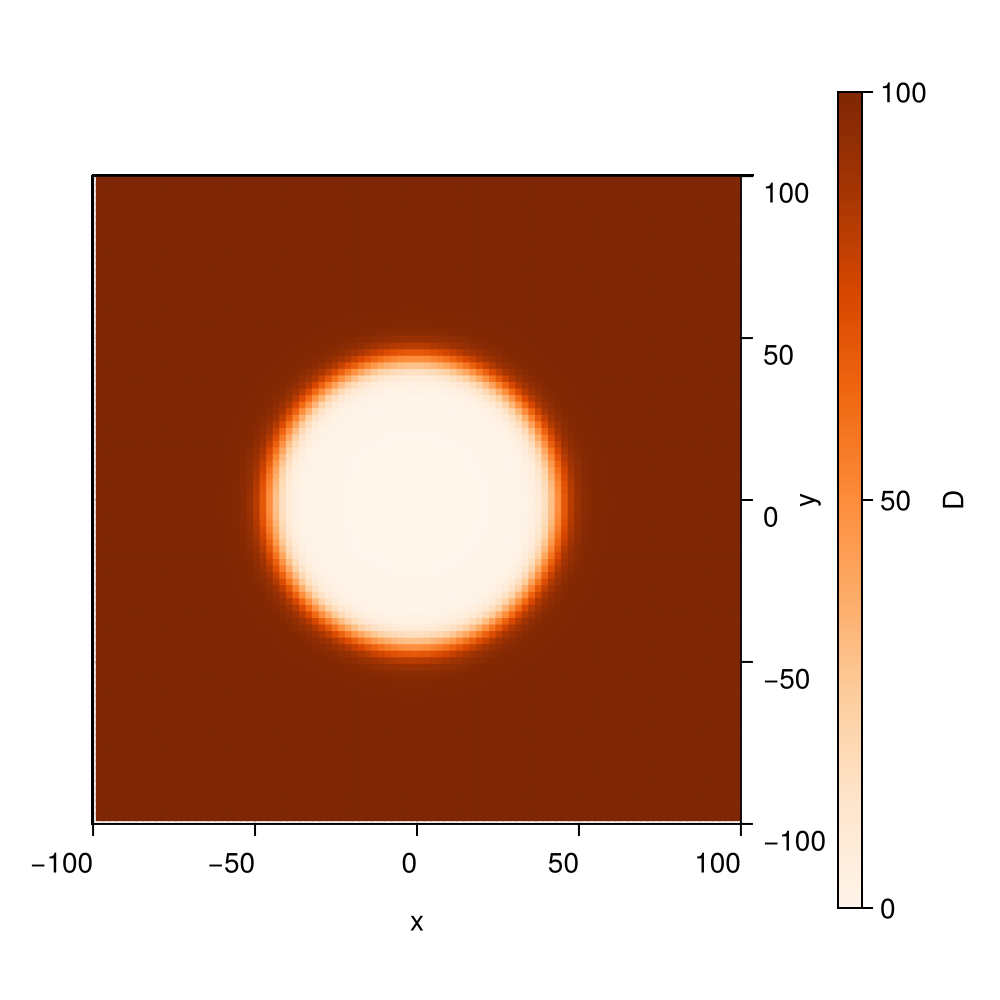

CairoMakie.Screen{IMAGE}


In [82]:
# Colormap común y colorrange fijo
# colormap = :viridis
# com,times=load_parameters_log("Tods_c.txt")
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(com.d))
colormap_c=:Oranges
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:D_eff]), com)))
colorrange_c = (0.0, com.D_eff[1])


fig = Figure(size=(500,500))



ax = Axis3(fig[1,1],
            azimuth=3*π/2,
            elevation=π/2,
            zlabelvisible=false,
            zticklabelsvisible=false,
            zgridvisible=false,
            zspinesvisible=false
        )
m = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
            com[:D_eff],
            colormap = colormap_c,
            colorrange = colorrange_c
        )




xlims!(-100,100)
ylims!(-100,100)


# Añadir colorbar común al final
Colorbar(fig[1, 2],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "D"
)

display(fig)



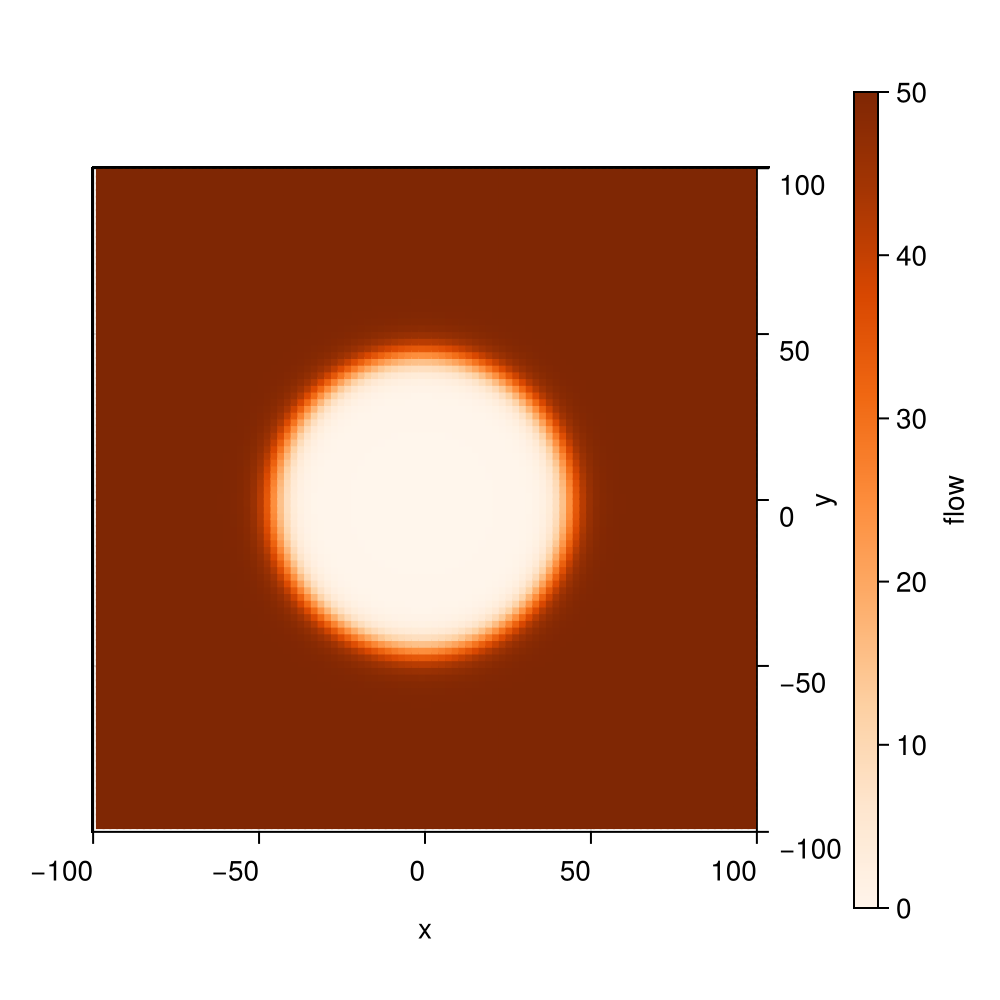

CairoMakie.Screen{IMAGE}


In [83]:
# Colormap común y colorrange fijo
# colormap = :viridis
# com,times=load_parameters_log("Tods_c.txt")
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(com.d))
colormap_c=:Oranges
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:alpha_eff]), com)))
colorrange_c = (0.0, com.alpha_eff[1])


fig = Figure(size=(500,500))



ax = Axis3(fig[1,1],
            azimuth=3*π/2,
            elevation=π/2,
            zlabelvisible=false,
            zticklabelsvisible=false,
            zgridvisible=false,
            zspinesvisible=false
        )
m = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
            com[:alpha_eff],
            colormap = colormap_c,
            colorrange = colorrange_c
        )




xlims!(-100,100)
ylims!(-100,100)


# Añadir colorbar común al final
Colorbar(fig[1, 2],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "flow"
)

display(fig)



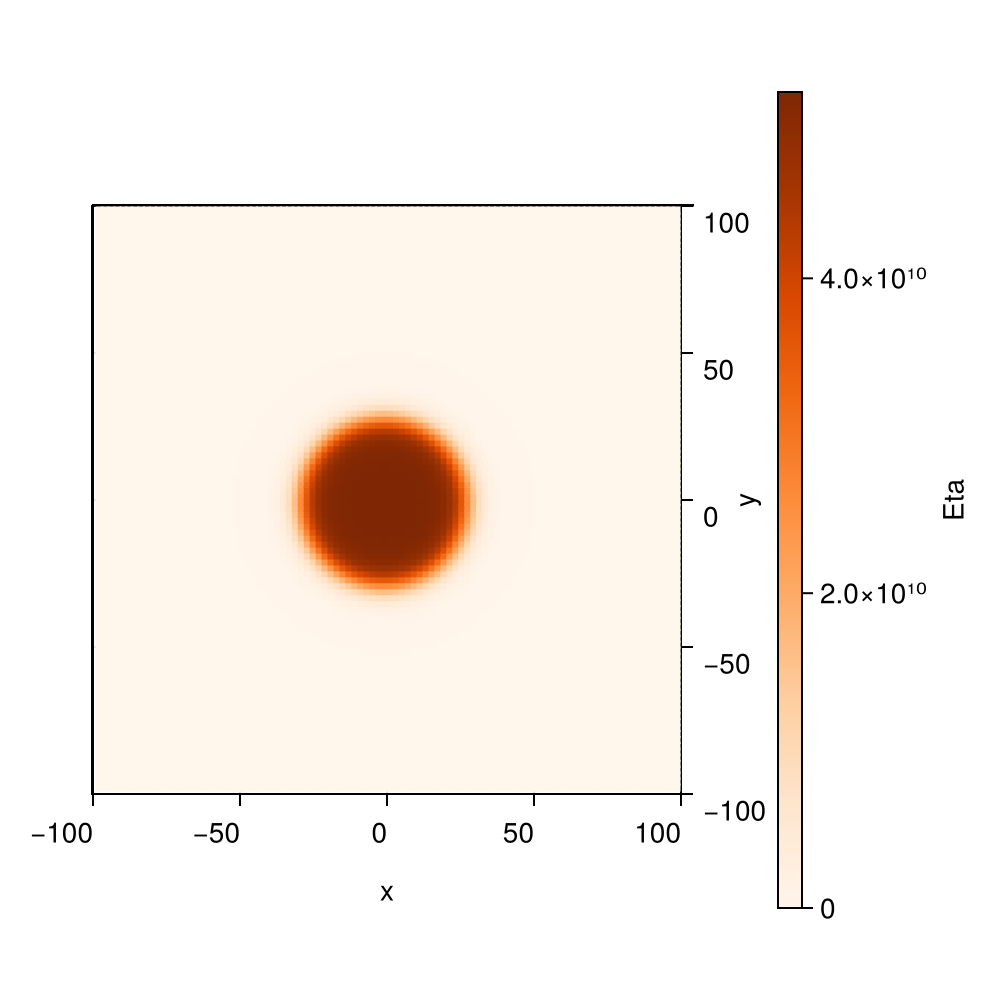

CairoMakie.Screen{IMAGE}


In [84]:
# Colormap común y colorrange fijo
# colormap = :viridis
# com,times=load_parameters_log("Tods_c.txt")
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(com.d))
colormap_c=:Oranges
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:Eta]), com)))
colorrange_c = (0.0, com.Eta[50,50])


fig = Figure(size=(500,500))



ax = Axis3(fig[1,1],
            azimuth=3*π/2,
            elevation=π/2,
            zlabelvisible=false,
            zticklabelsvisible=false,
            zgridvisible=false,
            zspinesvisible=false
        )
m = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
            com[:Eta],
            colormap = colormap_c,
            colorrange = colorrange_c
        )




xlims!(-100,100)
ylims!(-100,100)


# Añadir colorbar común al final
Colorbar(fig[1, 2],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "Eta"
)

display(fig)



In [85]:
com.Eta[50,40]

4.985810312813111e10

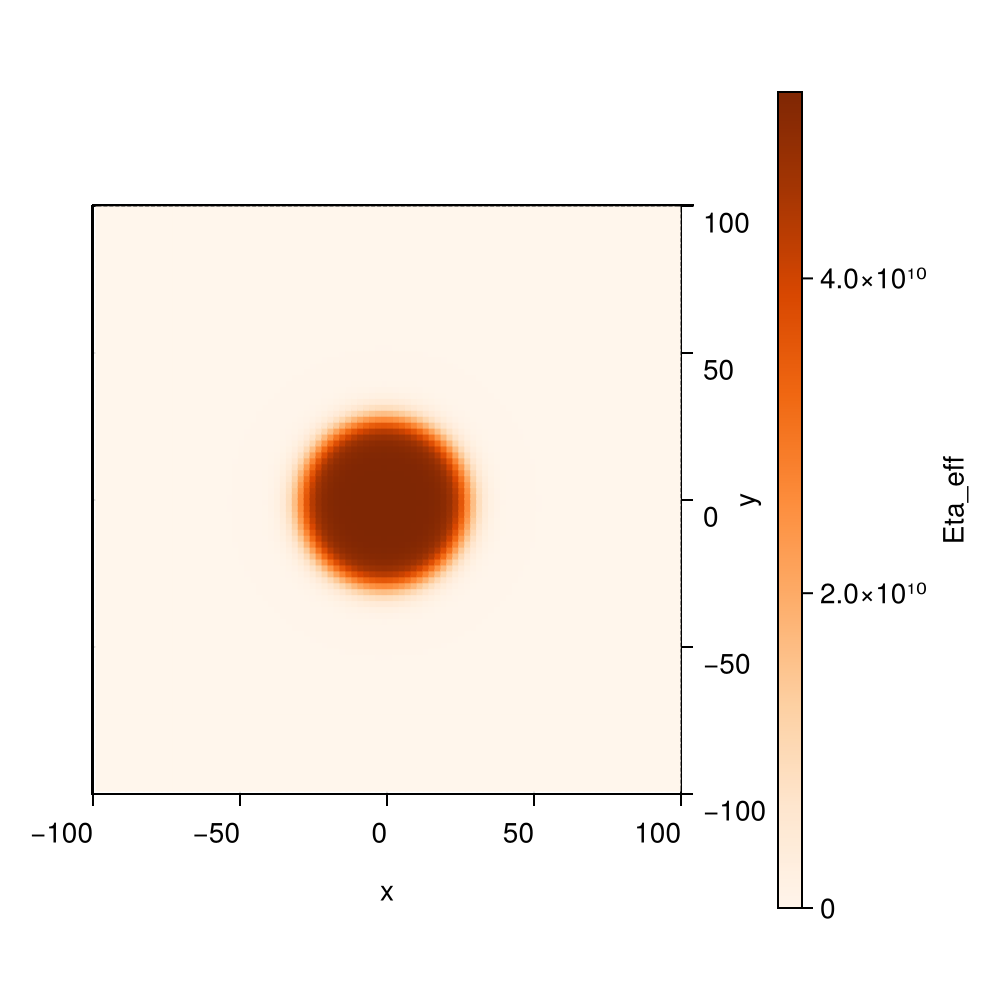

CairoMakie.Screen{IMAGE}


In [86]:
# Colormap común y colorrange fijo
# colormap = :viridis
# com,times=load_parameters_log("Tods_c.txt")
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(com.d))
colormap_c=:Oranges
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:Eta_eff]), com)))
colorrange_c = (0.0, com.Eta_eff[50,50])


fig = Figure(size=(500,500))



ax = Axis3(fig[1,1],
            azimuth=3*π/2,
            elevation=π/2,
            zlabelvisible=false,
            zticklabelsvisible=false,
            zgridvisible=false,
            zspinesvisible=false
        )
m = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
            com[:Eta_eff],
            colormap = colormap_c,
            colorrange = colorrange_c
        )




xlims!(-100,100)
ylims!(-100,100)


# Añadir colorbar común al final
Colorbar(fig[1, 2],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "Eta_eff"
)

display(fig)



In [87]:
com.Eta_eff[50,50],com.Eta_eff[50,30], com.Eta_eff[50,1]

(5.1841900728507904e10, 4.364165632029203e8, 2.5920000367568377e6)

In [49]:
# Colormap común y colorrange fijo
# colormap = :viridis
# com,times=load_parameters_log("Tods_c.txt")
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(com.d))
colormap_c=:Oranges
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:D_PGA]), com)))
colorrange_c = (0.0, com.D_PGA[1,1])


fig = Figure(size=(500,500))



ax = Axis3(fig[1,1],
            azimuth=3*π/2,
            elevation=π/2,
            zlabelvisible=false,
            zticklabelsvisible=false,
            zgridvisible=false,
            zspinesvisible=false
        )
m = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
            com[:D_PGA],
            colormap = colormap_c,
            colorrange = colorrange_c
        )




xlims!(-100,100)
ylims!(-100,100)


# Añadir colorbar común al final
Colorbar(fig[1, 2],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "D_PGA"
)

display(fig)



ErrorException: Invalid text boundingbox GeometryBasics.HyperRectangle{3, Float64}([109.0, NaN, 0.0], [7.783999919891357, 16.309999465942383, 0.0])

In [90]:
com.D_PGA[1,1]

0.0

In [91]:
prev_steps = 0
steps=Int(round(1/com.dt))
com.c = 0
com.growth = 0.1
com.beta_c = 0.01
com.Kc =0.5
com.D_c=50
com.alpha_c=25
open("Tods_c.txt", "w") do f
    # clear file at start
end
for i in 1:Int(com.NMedium[1])
    for j in 1:Int(com.NMedium[2])
        com.D_eff[i,j]=com.D_c[1]*(tanh(-0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2+1))+1)
        com.alpha_eff[i,j]=com.alpha_c[1]*(tanh(-0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2+1))+1)
        com.Eta[i,j]=10000*com.eta[1]*(tanh(0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2-15))+1)


    end

end
loadToPlatform!(com,preallocateAgents=N)


for step in 1+prev_steps:steps
    
    step!(com)

    for i in 1:Int(com.NMedium[1])
        for j in 1:Int(com.NMedium[2])
            com.D_eff[i,j]=com.D_c[1]*(tanh(-0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2+1))+1)
            com.alpha_eff[i,j]=com.alpha_c[1]*(tanh(-0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2+1))+1)
            com.Eta[i,j]=10000*com.eta[1]*(tanh(0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2-15))+1)


        end

    end

    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step)
        loadToPlatform!(com,preallocateAgents=N)
    end
end
bringFromPlatform!(com)

Step 1000 N: 1593
Step 2000 N: 1593
Step 3000 N: 1594
Step 4000 N: 1594
Step 5000 N: 1595
Step 6000 N: 1596
Step 7000 N: 1597
Step 8000 N: 1597
Step 9000 N: 1597
Step 10000 N: 1598


In [92]:
bringFromPlatform!(com)

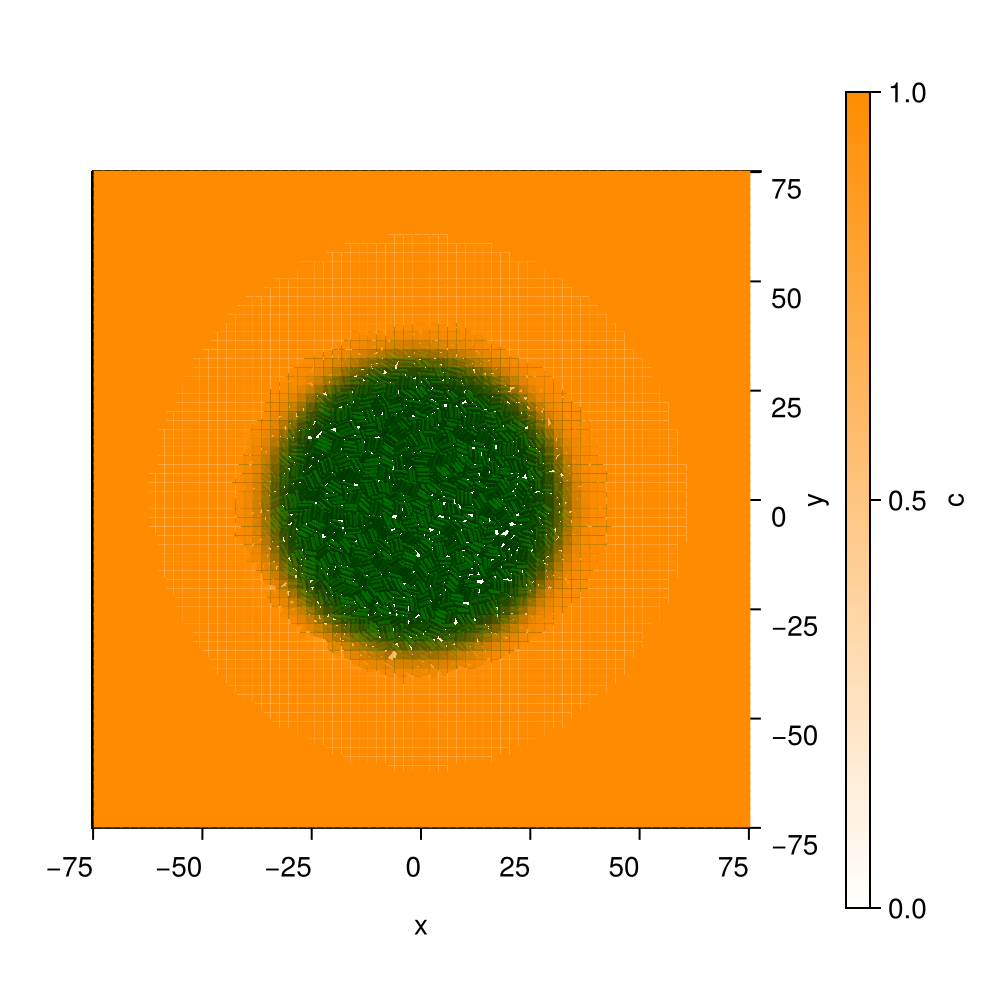

CairoMakie.Screen{IMAGE}


In [93]:
com_load,times=load_parameters_log("Tods_c.txt")
simBox_cpu = Array(com.simBox)  # copia a CPU

cmap_transp_orange = cgrad(
    [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
    256
)

colormap_c=cmap_transp_orange
# colormap_c=:Oranges
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))

fig = Figure(size=(500,500))

js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
            Float64.(hcat(com_load[j][:c]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-75,75)
    ylims!(-75,75)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)
display(fig)

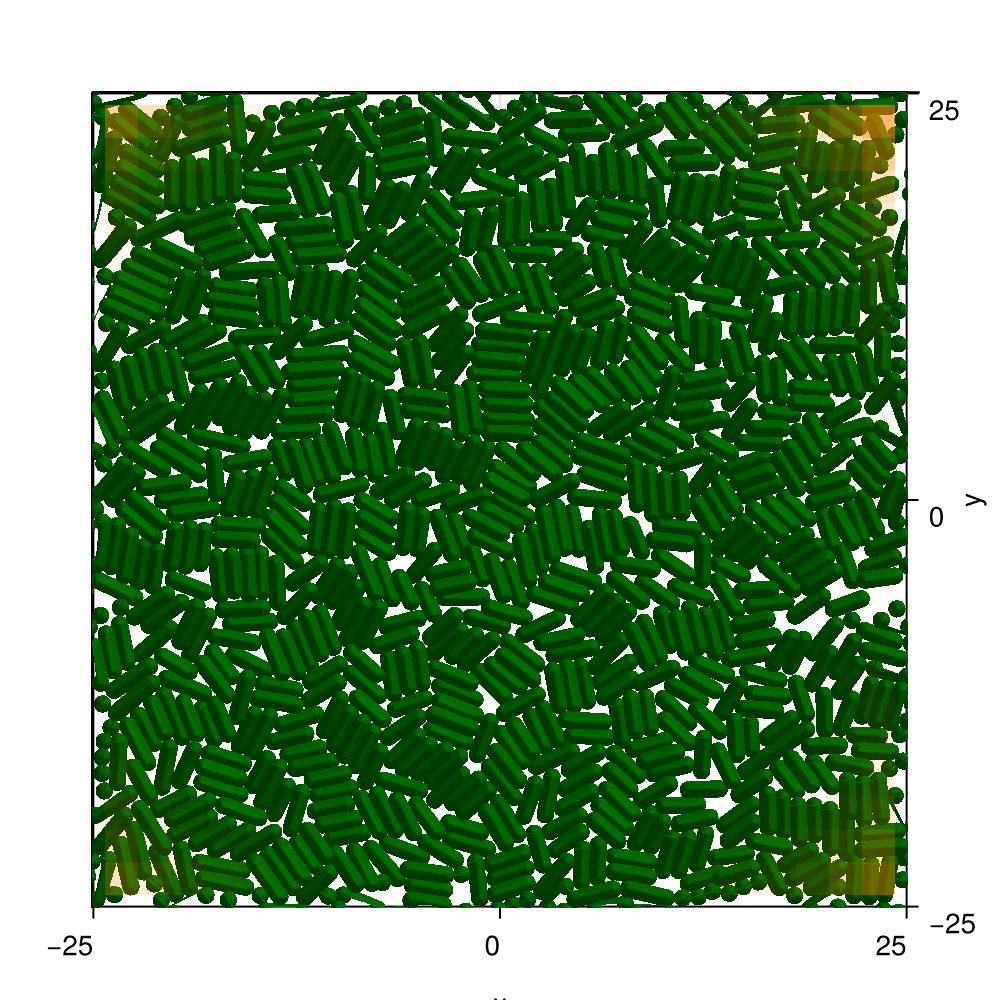

CairoMakie.Screen{IMAGE}


In [94]:
com_load,times=load_parameters_log("Tods_c.txt")
simBox_cpu = Array(com.simBox)  # copia a CPU

cmap_transp_orange = cgrad(
    [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
    256
)

colormap_c=cmap_transp_orange
# colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))

fig = Figure(size=(500,500))

js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
            Float64.(hcat(com_load[j][:c]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-25,25)
    ylims!(-25,25)
end

display(fig)

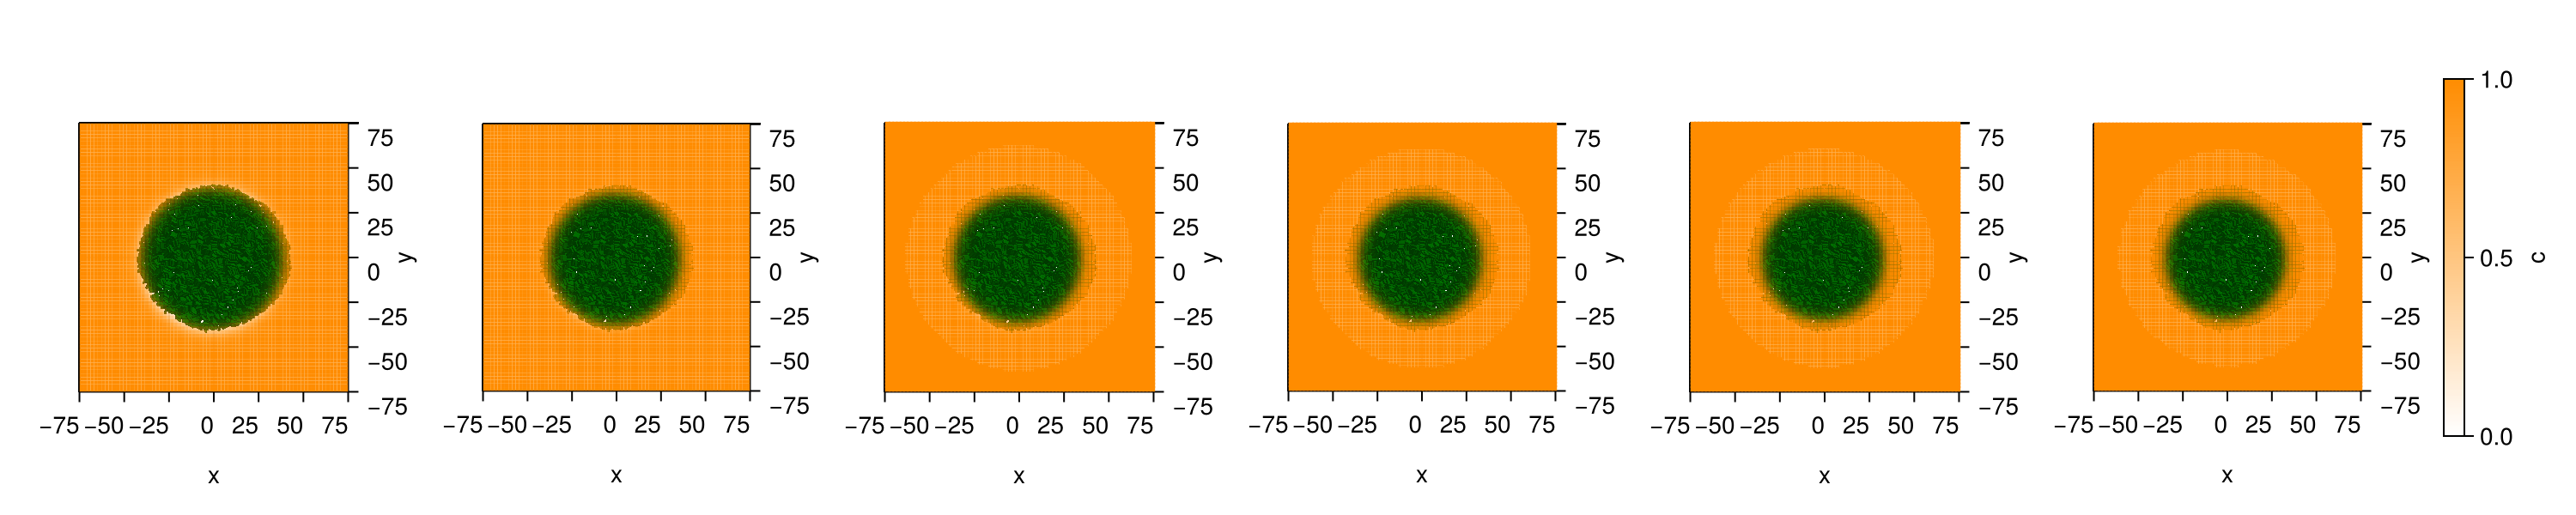

CairoMakie.Screen{IMAGE}


In [95]:
com_load,times=load_parameters_log("Tods_c.txt")
simBox_cpu = Array(com.simBox)  # copia a CPU

cmap_transp_orange = cgrad(
    [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
    256
)

colormap_c=cmap_transp_orange
# colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))
# colorrange_c = (0.0,  0.5)

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
            Float64.(hcat(com_load[j][:c]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-75,75)
    ylims!(-75,75)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)
display(fig)

In [96]:
com.c[50, 50], com.c[50, 25] ,  com.c[50, 40] 


(1.0837399634606276e-6, 0.9999729686300922, 0.0031524729737802165)

In [97]:
com.c[50, 50], com.c[50, 25] ,  com.c[50, 30] 


(1.0837399634606276e-6, 0.9999729686300922, 0.982034952829111)

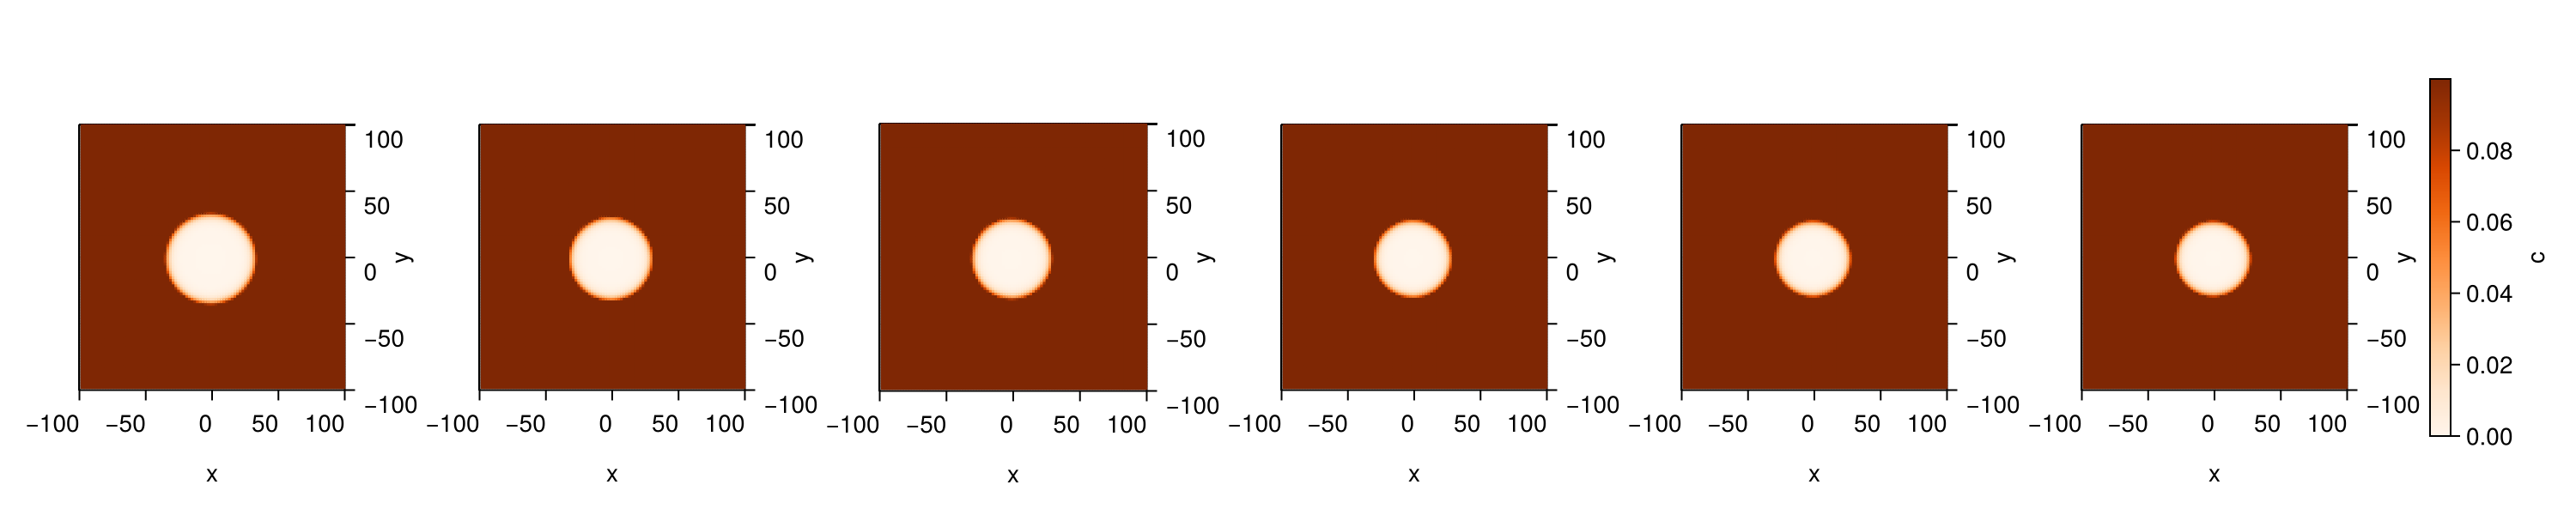

CairoMakie.Screen{IMAGE}


In [98]:
# Colormap común y colorrange fijo
# colormap = :viridis
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))
colorrange_c = (0.0,  0.1)


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
                Float64.(hcat(com_load[j][:c]...)),
                colormap = colormap_c,
                colorrange = colorrange_c
            )
    



    xlims!(-100,100)
    ylims!(-100,100)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)

display(fig)



In [99]:
maximum(maximum(p -> maximum(p[:PGA]), com_load))

0.0

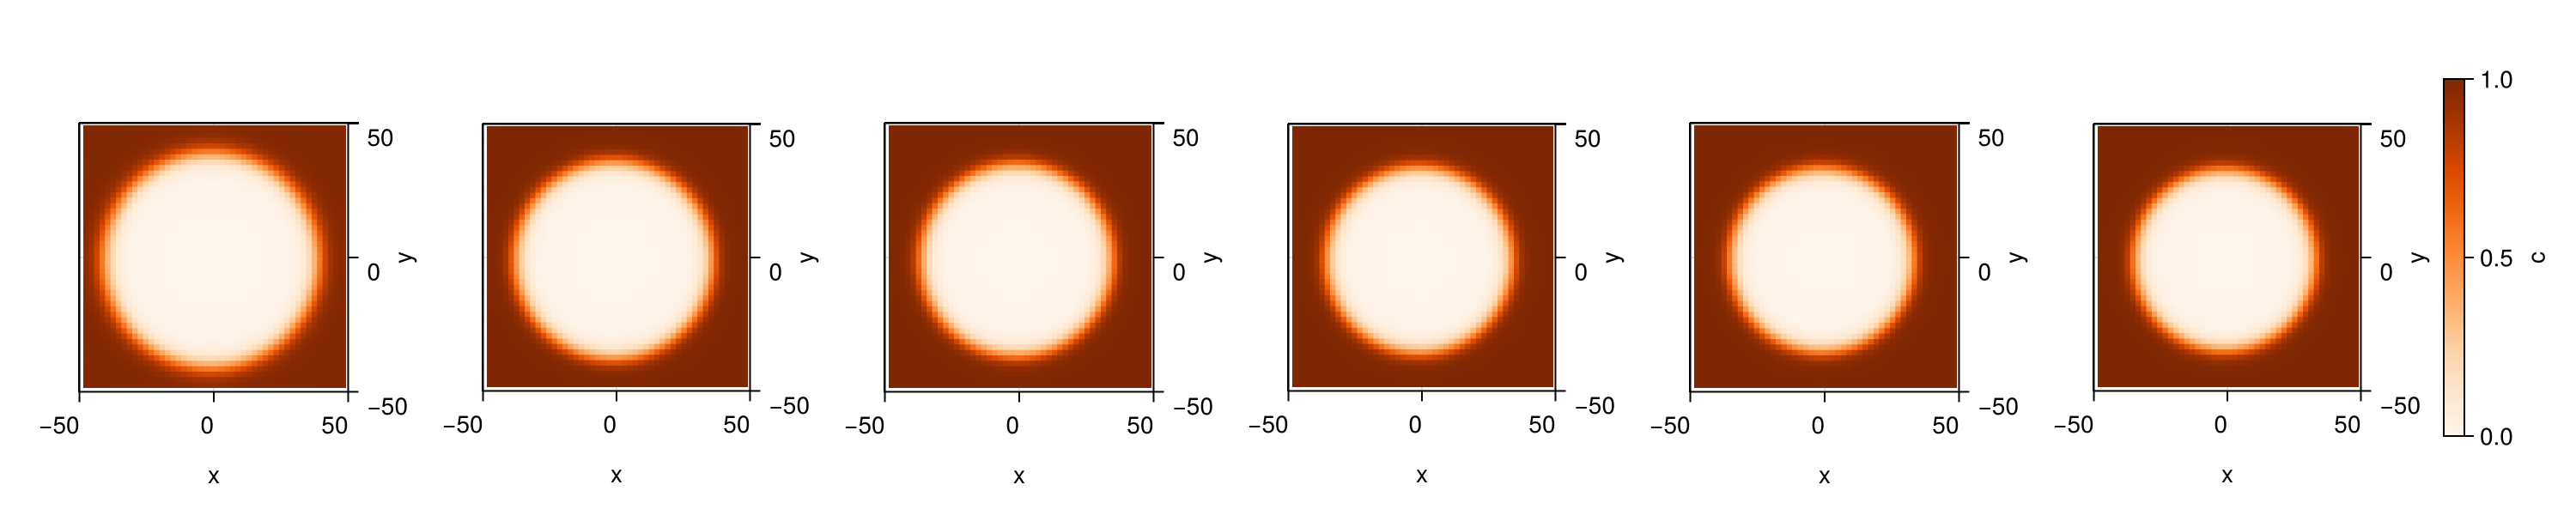

CairoMakie.Screen{IMAGE}


In [100]:
# Colormap común y colorrange fijo
# colormap = :viridis
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
                Float64.(hcat(com_load[j][:c]...)),
                colormap = colormap_c,
                colorrange = colorrange_c
            )
    



    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)

display(fig)



In [101]:
# cx, cy = 0, 15
# R2 = 100  # comparamos con el cuadrado del radio para evitar sqrt
# com.growth = 0.2
com.type =0
rmax = 0
for i in range(1,length(com.x))
    r = com.x[i]^2 + com.y[i]^2
    if r > rmax
        rmax = r
    end
    theta = atan(com.y[i], com.x[i])
    R =  800*exp(-50*theta^(2))+ 200
    prob = R^6/(R^6+r^6)
    if prob > rand()
        com.type[i] = 1
        com.g2[i] = 0.0
        com.growth[i] = 0.2
    else
        com.type[i] = 0
        com.growth[i] = 0
    end
end
com.rmax = sqrt(rmax)
println(sum(com.type .== 1))
log_community_state(com.parameters, steps)
com_load,times=load_parameters_log("Tods_c.txt")




242


(OrderedDict{Symbol, Any}[OrderedDict(:D_PGA => Any[Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.

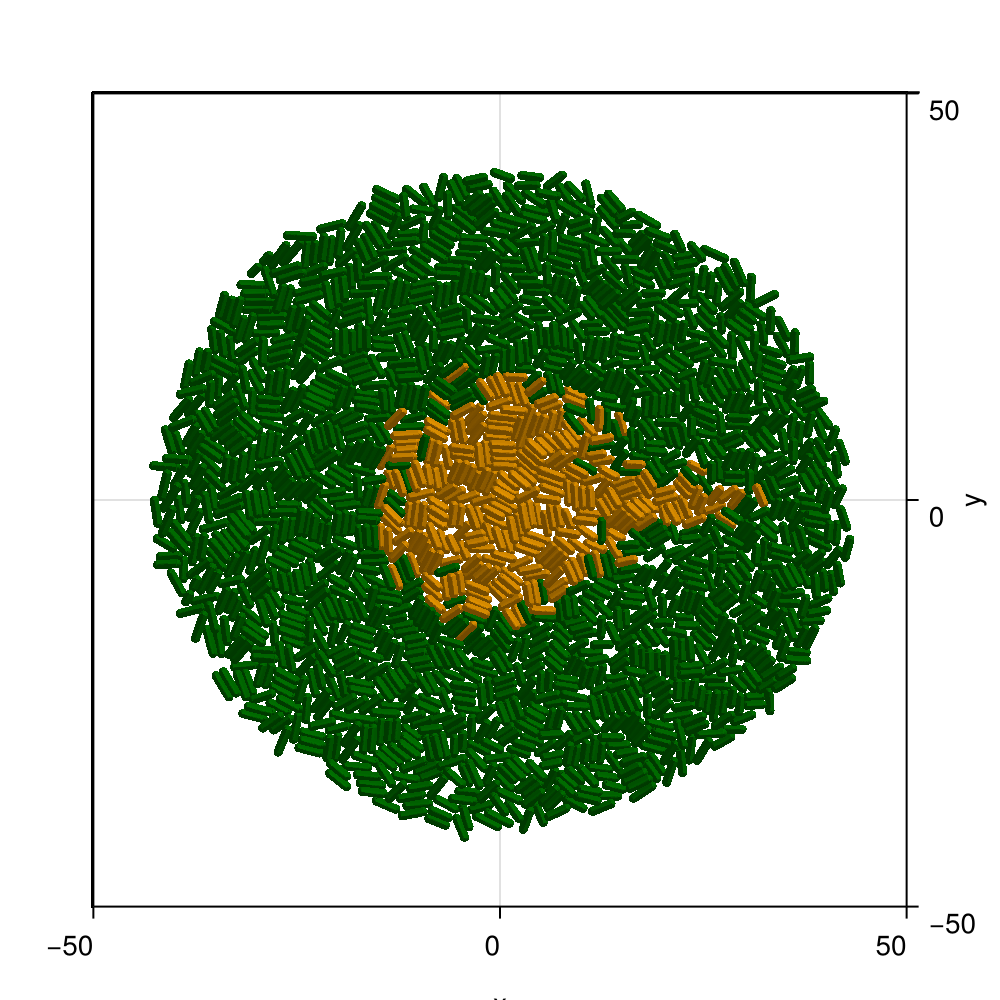

CairoMakie.Screen{IMAGE}


In [102]:
fig = Figure(size=(500,500))

# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

display(fig)

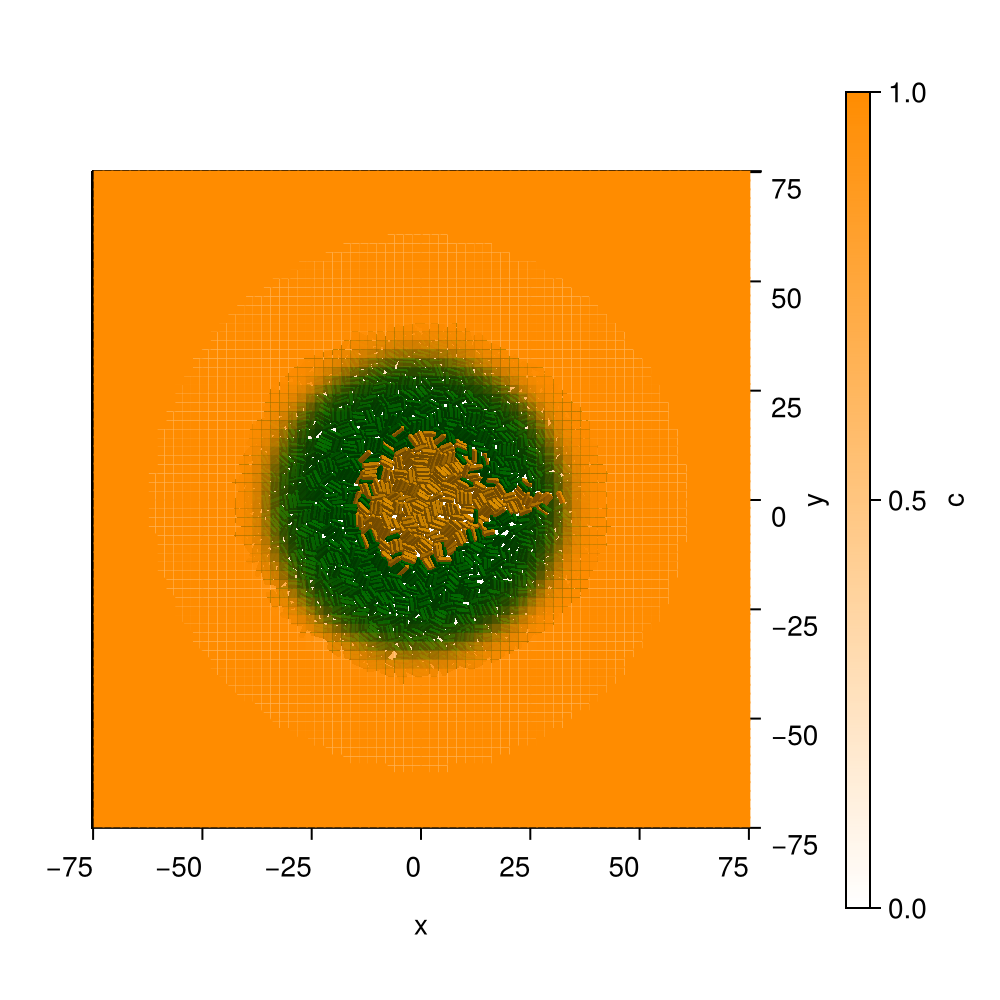

CairoMakie.Screen{IMAGE}


In [105]:
com_load,times=load_parameters_log("Tods_c.txt")
simBox_cpu = Array(com.simBox)  # copia a CPU

cmap_transp_orange = cgrad(
    [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
    256
)

colormap_c=cmap_transp_orange
# colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))

fig = Figure(size=(500,500))

js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
            Float64.(hcat(com_load[j][:c]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-75,75)
    ylims!(-75,75)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)
display(fig)

In [106]:
com_load,times=load_parameters_log("Tods_c.txt")

(OrderedDict{Symbol, Any}[OrderedDict(:D_PGA => Any[Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.

In [107]:
saveJLD2("biofil_templated.jld2",com)

In [108]:
com_templated = loadJLD2("biofil_templated.jld2")

Community with 1598 agents.


In [109]:
open("Motiles.txt", "w") do f
    # clear file at start
end

In [110]:

bringFromPlatform!(com)

com.PGA=0
com.alpha_PGA = 5
com.delta_PGA = 0.5
com.Kch = 0.01 
com.v = 0.3

log_community_state(com.parameters, 0, "Motiles.txt")

In [ ]:
prev_steps=0
# prev_steps=Int(round(0.4/com.dt))
steps=Int(round(40/com.dt))

loadToPlatform!(com,preallocateAgents=N)


for step in 1+prev_steps:steps
    
    step!(com)
    for i in 1:Int(com.NMedium[1])
        for j in 1:Int(com.NMedium[2])
            com.D_eff[i,j]=com.D_c[1]*(tanh(-0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2+1))+1)
            com.alpha_eff[i,j]=com.alpha_c[1]*(tanh(-0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2+1))+1)
            com.Eta[i,j]=10000*com.eta[1]*(tanh(0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2-15))+1)
        end

    end

    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step, "Motiles.txt")
        loadToPlatform!(com,preallocateAgents=N)
    end
end
bringFromPlatform!(com)


Step 1000 N: 1598
Step 2000 N: 1598
Step 3000 N: 1598
Step 4000 N: 1598
Step 5000 N: 1598
Step 6000 N: 1598
Step 7000 N: 1598
Step 8000 N: 1598
Step 9000 N: 1598
Step 10000 N: 1598
Step 11000 N: 1598
Step 12000 N: 1598
Step 13000 N: 1598
Step 14000 N: 1598
Step 15000 N: 1598
Step 16000 N: 1598
Step 17000 N: 1598
Step 18000 N: 1598
Step 19000 N: 1598
Step 20000 N: 1598
Step 21000 N: 1598
Step 22000 N: 1598
Step 23000 N: 1598
Step 24000 N: 1598
Step 25000 N: 1598
Step 26000 N: 1598
Step 27000 N: 1598
Step 28000 N: 1598
Step 29000 N: 1598
Step 30000 N: 1598


In [ ]:
com_load,times=load_parameters_log("Motiles.txt")


In [ ]:
fig = Figure(size=(500,500))

# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    xlims!(-75,75)
    ylims!(-75,75)
end

display(fig)

In [ ]:
fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
# js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    xlims!(-75,75)
    ylims!(-75,75)
end

display(fig)

In [ ]:
# Colormap común y colorrange fijo
# colormap = :viridis
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_PGA=:Greens
colorrange_PGA = (0.0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PGA)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PGA)[1]),
                Float64.(hcat(com_load[j][:PGA]...)),
                colormap = colormap_PGA,
                colorrange = colorrange_PGA
            )
    



    xlims!(-100,100)
    ylims!(-100,100)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_PGA,
    colorrange = colorrange_PGA,
    label = "PGA"
)

display(fig)



In [ ]:
# Colormap común y colorrange fijo
# colormap = :viridis
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
                Float64.(hcat(com_load[j][:c]...)),
                colormap = colormap_c,
                colorrange = colorrange_c
            )
    



    xlims!(-80,80)
    ylims!(-80,80)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)

display(fig)



In [ ]:
cmap_transp_green = cgrad(
    [RGBAf(0, 1, 0.3, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(0, 1, 0.3, 1.0)],  # verde con alfa 1 (opaco)
    256
)
cmap_transp_orange = cgrad(
    [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
    256
)

# Colormap común y colorrange fijo
# colormap = :viridis
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_PGA=cmap_transp_green
# colormap_PGA=:Greens
colorrange_PGA = (0.0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))

colormap_c=cmap_transp_orange
# colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m1 = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PGA)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PGA)[1]),
                Float64.(hcat(com_load[j][:PGA]...)),
                colormap = colormap_PGA,
                colorrange = colorrange_PGA
            )
    m2 = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
                Float64.(hcat(com_load[j][:c]...)),
                colormap = colormap_c,
                colorrange = colorrange_c
            )



    xlims!(-100,100)
    ylims!(-100,100)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_PGA,
    colorrange = colorrange_PGA,
    label = "PGA"
)
Colorbar(fig[1, length(js) + 2],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)

display(fig)



In [ ]:
# Colormap común y colorrange fijo
# colormap = :viridis
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_PGA=:Greens
colorrange_PGA = (0.0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PGA)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PGA)[1]),
                Float64.(hcat(com_load[j][:PGA]...)),
                colormap = colormap_PGA,
                colorrange = colorrange_PGA
            )
    



    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_PGA,
    colorrange = colorrange_PGA,
    label = "PGA"
)

display(fig)



In [ ]:
# Colormap común y colorrange fijo
# colormap = :viridis
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:Eta]), com_load)))
# colorrange_c = (0.0,  com.Eta_eff[50,50])


fig = Figure(size=(500,500))

js = [length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
                Float64.(hcat(com_load[j][:Eta_eff]...)),
                colormap = colormap_c,
                colorrange = colorrange_c
            )
    



    xlims!(-100,100)
    ylims!(-100,100)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "eta_eff"
)

display(fig)



In [ ]:
# Colormap común y colorrange fijo
# colormap = :viridis
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:D_PGA]), com_load)))
# colorrange_c = (0.0,  com.D_PGA[50,50])


fig = Figure(size=(500,500))

js = [length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
                Float64.(hcat(com_load[j][:D_PGA]...)),
                colormap = colormap_c,
                colorrange = colorrange_c
            )
    



    xlims!(-100,100)
    ylims!(-100,100)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "D_PGA"
)

display(fig)



In [ ]:
function plotMixedAgents!(ax, x, y, d, l, angle, type, p; kargs...)
    # Diccionario de tipos a colormaps (puedes extenderlo con más tipos y colores)
    colormap_dict = Dict(
        0 => :Greens,
        1 => :Oranges,
        2 => :Purples,
        3 => :Reds,
        4 => :Blues,
        5 => :Greys
    )

    for (xi, yi, li, di, ai, ti, pi) in zip(x, y, l, d, angle, type, p)
        # Colormap según tipo, o uno genérico si no está definido
        colormap = get(colormap_dict, ti, :viridis)

        # Color numérico según p
        colorval = pi

        # Esferas en los extremos
        for dx in (-1, 1)
            meshscatter!(ax,
                [xi + dx * li/2 * cos(ai)],
                [yi + dx * li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = colorval,
                colormap = colormap,
                kargs...
            )
        end

        # Cuerpo alargado
        meshscatter!(ax,
            [xi],
            [yi];
            marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
            markersize = [Point3f(li, di/2, di/2)],
            rotation = [ai],
            color = colorval,
            colormap = colormap,
            kargs...
        )
    end
    return
end


In [ ]:

# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax = Axis(grid[1, 1]; aspect = DataAspect())


# colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colorrange = (0.0,  2.)

Makie.record(fig, "Tods.mp4", 1:5:Int(length(com_load)); framerate = 10) do j
 
    Makie.empty!(ax)
   
    plotMixedAgents!(
        ax,
        com_load[j][:x],
        com_load[j][:y],
        com_load[j][:d],
        com_load[j][:l],
        com_load[j][:theta],
        com_load[j][:type],
        com_load[j][:d],
        colorrange = colorrange
    )


    # xlims!(ax, - (com_load[j][:rmax][1]+5), com_load[j][:rmax][1]+5)
    # ylims!(ax, - (com_load[j][:rmax][1]+5),  com_load[j][:rmax][1]+5)
    # xlims!(ax, - (75), 75)
    # ylims!(ax, - (75),  75)

    xlims!(ax, - (com.rmax[1] +5), com.rmax[1] +5)
    ylims!(ax, - (com.rmax[1] +5),  com.rmax[1] +5)
    
end


In [76]:

# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax = Axis(grid[1, 1]; aspect = DataAspect())

cmap_transp_green = cgrad(
    [RGBAf(0, 1, 0.3, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(0, 1, 0.3, 1.0)],  # verde con alfa 1 (opaco)
    256
)
cmap_transp_orange = cgrad(
    [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
    256
)

simBox_cpu = Array(com.simBox)  # copia a CPU
colormap_PGA=cmap_transp_green
# colormap_PGA=:Greens
colorrange_PGA = (0.0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))

colormap_c=cmap_transp_orange
# colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))

# colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colorrange = (0.0,  2.)
Colorbar(fig[1, 2],
    colormap = colormap_PGA,
    colorrange = colorrange_PGA,
    label = "PGA"
)
Colorbar(fig[1, 3],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)

Makie.record(fig, "Tods_fields.mp4", 1:2:Int(length(com_load)); framerate = 5) do j
 
    Makie.empty!(ax)
   
    plotMixedAgents!(
        ax,
        com_load[j][:x],
        com_load[j][:y],
        com_load[j][:d],
        com_load[j][:l],
        com_load[j][:theta],
        com_load[j][:type],
        com_load[j][:d],
        colorrange = colorrange
    )
    m1 = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PGA)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PGA)[1]),
                Float64.(hcat(com_load[j][:PGA]...)),
                colormap = colormap_PGA,
                colorrange = colorrange_PGA
            )
    m2 = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
                Float64.(hcat(com_load[j][:c]...)),
                colormap = colormap_c,
                colorrange = colorrange_c
            )


    xlims!(ax, - (com_load[j][:rmax][1]+5), com_load[j][:rmax][1]+5)
    ylims!(ax, - (com_load[j][:rmax][1]+5),  com_load[j][:rmax][1]+5)
end


"Tods_fields.mp4"